In [1]:
import sys
sys.path.append("..")

In [2]:
from omegaconf import OmegaConf
from itertools import combinations
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import os
import re

In [3]:
from sentence_transformers import SentenceTransformer, util
from datasets import load_dataset

/Users/c/Library/Caches/pypoetry/virtualenvs/pesto-R9MfnoAy-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from presto import Presto

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [163]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"\usepackage{amssymb}\usepackage{amsmath}"

### Load data and results

In [139]:
paper_figure_path = "../../ICML2024_EmbedEQ/images"

In [7]:
config = OmegaConf.load("../config.yml")

In [8]:
models = {m: SentenceTransformer(*m.split()) for m in config.models}
datasets = {d: load_dataset(*d.split()) for d in config.datasets}

In [9]:
with open("../data/combined_results.pkl", "rb") as f:
    results = pickle.load(f)

In [10]:
metric = Presto(max_homology_dim=config.max_homology_dim, n_components=config.n_components, normalize=config.normalize)

### Average landscapes for varying numbers of projections

In [181]:
def get_short_name(dataset):
    if "patent" in dataset:
        return "patents"
    elif "arxiv" in dataset:
        return "arxiv"
    elif "cnn" in dataset:
        return "cnn"
    elif "xsum" in dataset:
        return "bbc"
    else:
        raise NotImplementedError(dataset)

def get_long_name(dataset):
    if dataset == "patents":
        return 'big_patent a'
    elif dataset == "arxiv":
        return 'gfissore/arxiv-abstracts-2021'
    elif dataset == "cnn":
        return 'cnn_dailymail 3.0.0'
    elif dataset == "bbc":
        return 'EdinburghNLP/xsum'
    else:
        raise NotImplementedError(dataset)
    
    
def create_score_df(scores):
    df = pd.DataFrame(scores).T.sort_values(0, ascending=False).reset_index().rename(
        {"level_0":"m1", "level_1":"m2", 0:"dim0", 1:"dim1", 2:"dim2"}, axis=1)
    df["m1_dataset"] = df.m1.map(lambda x:get_short_name(x[0]))
    df["m2_dataset"] = df.m2.map(lambda x:get_short_name(x[0]))
    df["datasets"] = df.m1_dataset + "/" + df.m2_dataset
    df["m1_model"] = df.m1.map(lambda x:x[1])
    df["m2_model"] = df.m2.map(lambda x:x[1])
    df["models"] = df.m1_model + "/" + df.m2_model
    df["m1_n_samples"] = df.m1.map(lambda x:x[2])
    df["m2_n_samples"] = df.m2.map(lambda x:x[2])
    df["sample_diff"] = [abs(x-y) for x,y in zip(df.m1_n_samples, df.m2_n_samples)]
    if df.m1.map(len)[0] == 4:
        df["m1_n_projections"] = df.m1.map(lambda x:x[3])
        df["m2_n_projections"] = df.m2.map(lambda x:x[3])
        df["projection_diff"] = [abs(x-y) for x,y in zip(df.m1_n_projections, df.m2_n_projections)]
    df["aggregate_presto"] = df.dim0 + df.dim1 + df.dim2
    df["average_presto"] = df["aggregate_presto"] / 3
    return df

In [34]:
avg_landscapes = dict()
finegrained = dict()
finegrained_scores = dict()
for dataset, v1 in results.items():
    for model, v2 in v1.items():
        for n_samples, v3 in v2.items():
            avg_landscapes[(dataset, model, n_samples)] = metric.average_landscape(v3["landscapes"])
            for n_projections in config.n_projections:
                finegrained[(dataset, model, n_samples, n_projections)] = metric.average_landscape({i:v3["landscapes"][i][:n_projections] for i in range(config.max_homology_dim + 1)})
for (k1,v1), (k2,v2) in list(combinations(finegrained.items(),2)) + [((k1,v1),(k1,v1)) for k1, v1 in finegrained.items()]:
    finegrained_scores[(k1,k2)] = metric.compute_presto_scores(v1, v2)

In [35]:
df_fine = create_score_df(finegrained_scores)
print(df_fine.shape)
df_fine.head(2)

(205120, 19)


,m1,m2,dim0,dim1,dim2,m1_dataset,m2_dataset,datasets,m1_model,m2_model,models,m1_n_samples,m2_n_samples,sample_diff,m1_n_projections,m2_n_projections,projection_diff,aggregate_presto,average_presto
0,"(gfissore/arxiv-abstracts-2021, all-distilrobe...","(EdinburghNLP/xsum, all-distilroberta-v1, 1024...",0.679083,0.080847,0.032655,arxiv,bbc,arxiv/bbc,all-distilroberta-v1,all-distilroberta-v1,all-distilroberta-v1/all-distilroberta-v1,16384,1024,15360,4,4,0,0.792586,0.264195
1,"(gfissore/arxiv-abstracts-2021, all-distilrobe...","(EdinburghNLP/xsum, all-distilroberta-v1, 1024...",0.657864,0.067605,0.028935,arxiv,bbc,arxiv/bbc,all-distilroberta-v1,all-distilroberta-v1,all-distilroberta-v1/all-distilroberta-v1,16384,1024,15360,8,4,4,0.754404,0.251468


In [36]:
df_fine.to_csv("finegrained_score_data.csv.gz")

### Same model, same dataset – looking at effect of sample size and number of projections

In [40]:
sorted_models = ['all-mpnet-base-v2','all-MiniLM-L6-v2', 'all-distilroberta-v1','multi-qa-distilbert-cos-v1']
sorted_datasets = ['arxiv', 'bbc', 'cnn', 'patents']

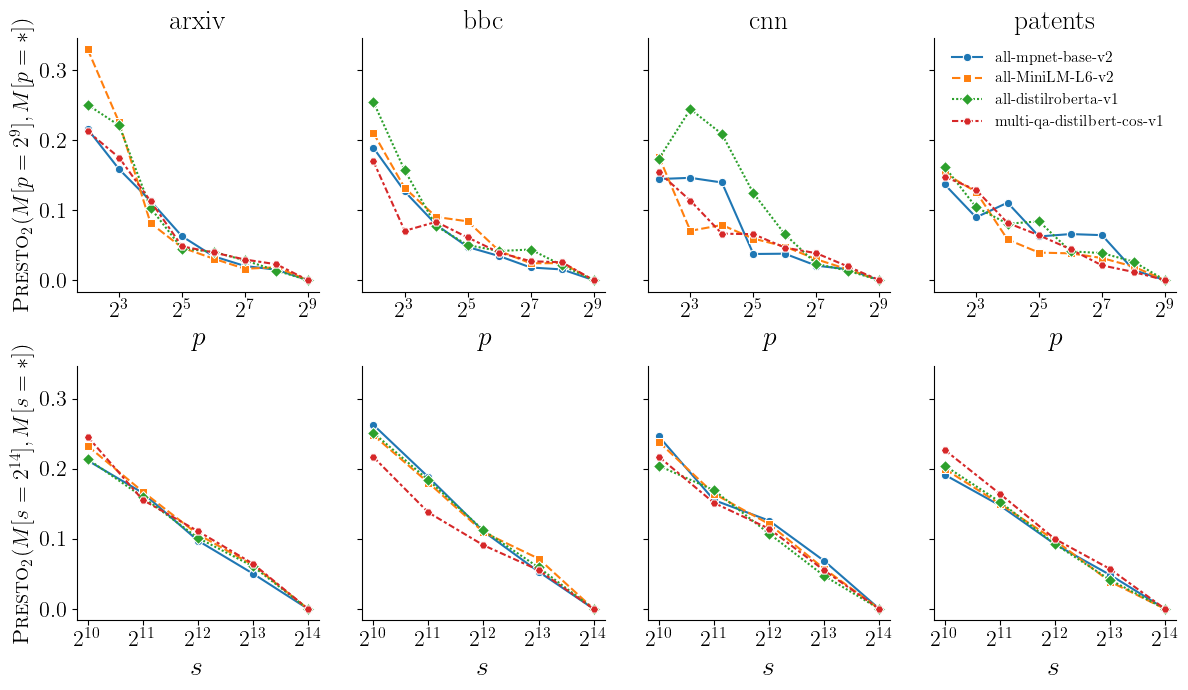

In [140]:
samples_m2 = 16384
projections_m2 = 512
label_fontsize = 16
legend_fontsize = 12
title_fontsize = 20
df = df_fine.query("m1_model == m2_model and m1_dataset == m2_dataset and m2_n_samples == @samples_m2 and m2_n_projections == @projections_m2"
                  ).sort_values("m1_model", key=lambda vec:vec.map(lambda x:sorted_models.index(x)))
fig, ax = plt.subplots(2,len(datasets),figsize=(3 * len(datasets),3.5 * 2), sharey=True, sharex=False)
for idx,dataset in enumerate(sorted_datasets):
    sns.lineplot(data=df.query("m1_dataset == @dataset and m1_n_samples == m2_n_samples"), 
                 x="m1_n_projections", 
                 y="aggregate_presto", 
                 hue="m1_model",
                 style="m1_model",
                 ax=ax[0][idx],
                 markers="osDH",
                 legend=False if idx != len(datasets) - 1 else True
                )
    ax[0][idx].set_title(dataset.split("/")[-1], fontsize=title_fontsize)
    ax[0][idx].set_ylabel(r"\textsc{Presto}"+"$_2(M[p = 2^{9}],M[p = *])$", fontsize=label_fontsize)
    ax[0][idx].set_xlabel(rf"$p$", fontsize=title_fontsize)
    ax[0][idx].set_xscale("log", base=2)
    
    sns.lineplot(data=df.query("m1_dataset == @dataset and m1_n_projections == m2_n_projections"), 
                 x="m1_n_samples", 
                 y="aggregate_presto", 
                 hue="m1_model",
                 style="m1_model",
                 ax=ax[1][idx],
                 markers="osDH", legend=False
                )
    ax[1][idx].set_ylabel(r"\textsc{Presto}"+"$_2(M[s = 2^{14}],M[s = *])$", fontsize=label_fontsize)
    ax[1][idx].set_xlabel(rf"$s$", fontsize=title_fontsize)
    ax[1][idx].set_xscale("log", base=2)
ax[0][-1].legend(title="",frameon=False, fontsize=legend_fontsize - 1)
ax[0][0].set_yticks(np.arange(0,0.31,0.1))
for axx in ax[0]:
    axx.set_xticks([2**x for x in range(3,10,2)])
    axx.set_xticklabels([rf"$2^{x}$" for x in range(3,10,2)], fontsize=label_fontsize)
for axx in ax[1]:
    axx.set_xticks([2**x for x in range(10,15,1)])
    axx.set_xticklabels([r"$2^{"+str(x)+r"}$" for x in range(10,15,1)], fontsize=label_fontsize)
for axx in [ax[0][0],ax[1][0]]:
    axx.set_yticklabels([round(x,1) for x in np.arange(0,0.31,0.1)], fontsize=label_fontsize)
sns.despine(fig)
plt.tight_layout()
plt.savefig(f"{paper_figure_path}/effects_sample-size_n-projections.pdf", bbox_inches="tight", transparent=True)

### Different model, same dataset, same sample size, same number of projections

In [97]:
samples_m2 = 16384
projections_m2 = 512
label_fontsize = 14
legend_fontsize = 12
df = df_fine.query("m1_dataset == m2_dataset and m1_n_samples == m2_n_samples == @samples_m2 and m1_n_projections == m2_n_projections == @projections_m2")

In [98]:
pdfs = dict()
for dataset in df.m1_dataset.unique():
    pdf = df.query("m1_dataset == @dataset").pivot(index=["m1_model"], columns=["m2_model"], values="aggregate_presto"
                                                  ).sort_index(key=lambda v:v.map(lambda x:x.lower()), ascending=False)
    pdf = pdf[sorted(pdf.columns, key=lambda x:x.lower())]
    pdfs[dataset] = pdf.loc[[*pdf.index[1:], pdf.index[0]]][[pdf.columns[-1],*pdf.columns[:-1]]].fillna(0)
    pdfs[dataset] += pdfs[dataset].T

In [104]:
melted_df = df_fine.query("m1_n_samples == m2_n_samples == @samples_m2 and m1_n_projections == m2_n_projections == @projections_m2"
             ).melt(id_vars=["m1_dataset", "m2_dataset", "m1_model", "m2_model"], value_vars="aggregate_presto", 
                    value_name="score").pivot(index=["m1_dataset","m1_model"], columns=["m2_dataset","m2_model"], values=["score"])

In [105]:
melted_df.columns = melted_df.columns.droplevel()

In [106]:
for idx1 in melted_df.index:
    for idx2 in melted_df.columns:
        if pd.isna(melted_df.at[idx1,idx2]) and idx2 in melted_df.columns and idx1 in melted_df.index:
            melted_df.at[idx1,idx2] = melted_df.at[idx2,idx1]

In [107]:
melted_df = melted_df.sort_index()[sorted(melted_df.columns)]

In [108]:
import scipy.spatial as sp, scipy.cluster.hierarchy as hc

In [109]:
method = "ward"
metric = "euclidean"

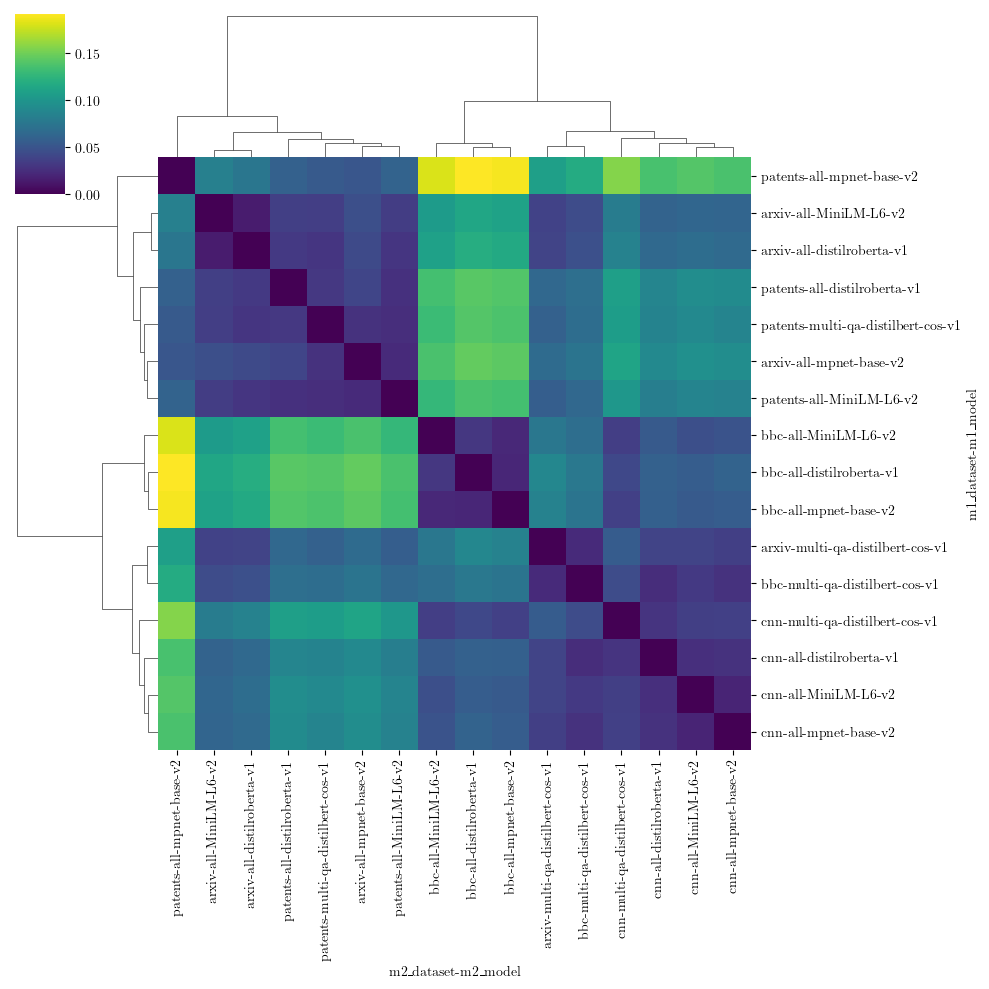

In [141]:
linkage = hc.linkage(sp.distance.squareform(melted_df), method=method, metric=metric)
sns.clustermap(melted_df, row_linkage=linkage, col_linkage=linkage, cmap="viridis")
plt.savefig(f"{paper_figure_path}/effects_dataset_model_clustermap_method-{method}_metric-{metric}.pdf", bbox_inches="tight", transparent=True)

In [143]:
method = "ward"
metric = "euclidean"
for idx,dataset in enumerate(sorted_datasets):
    melted_small = df_fine.query("m1_n_samples == m2_n_samples == @samples_m2 and m1_n_projections == m2_n_projections == @projections_m2 "
                  + "and m1_dataset == m2_dataset == @dataset"
                 ).pivot(index="m1_model", columns="m2_model", values="aggregate_presto").sort_index().fillna(0)
    melted_small += melted_small.T
    linkage = hc.linkage(sp.distance.squareform(melted_small), method=method, metric=metric)
    sns.clustermap(melted_small, row_linkage=linkage, col_linkage=linkage, cmap="viridis")
    plt.savefig(f"{paper_figure_path}/effects_model-only_dataset-{dataset}_clustermap_method-{method}_metric-{metric}.pdf", bbox_inches="tight", transparent=True)
    plt.close()

In [142]:
method = "ward"
metric = "euclidean"
for idx,model in enumerate(sorted_models):
    melted_small = df_fine.query("m1_n_samples == m2_n_samples == @samples_m2 and m1_n_projections == m2_n_projections == @projections_m2 "
                  + "and m1_model == m2_model == @model"
                 ).pivot(index="m1_dataset", columns="m2_dataset", values="aggregate_presto").sort_index().fillna(0)
    melted_small += melted_small.T
    linkage = hc.linkage(sp.distance.squareform(melted_small), method=method, metric=metric)
    sns.clustermap(melted_small, row_linkage=linkage, col_linkage=linkage, cmap="viridis")
    plt.savefig(f"{paper_figure_path}/effects_data-only_model-{model}_clustermap_method-{method}_metric-{metric}.pdf", bbox_inches="tight", transparent=True)
    plt.close()

### Model comparisons with varying number of projections (bands are different sample sizes)

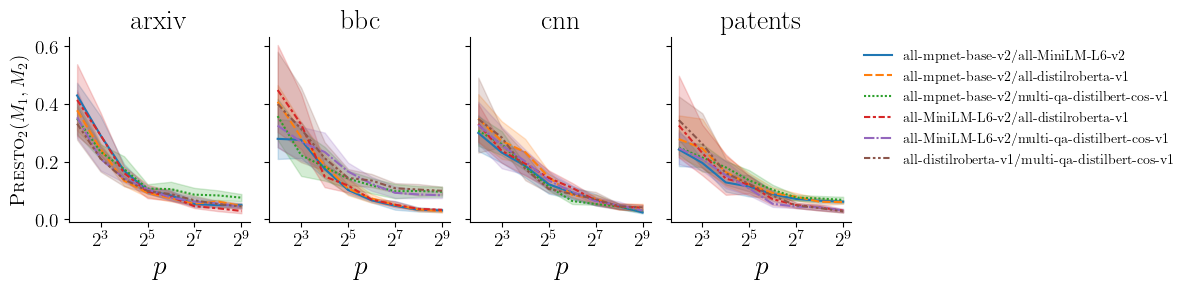

In [138]:
sorted_model_pairs = [
       'all-mpnet-base-v2/all-MiniLM-L6-v2',
       'all-mpnet-base-v2/all-distilroberta-v1',
       'all-mpnet-base-v2/multi-qa-distilbert-cos-v1',
        'all-MiniLM-L6-v2/all-distilroberta-v1',
       'all-MiniLM-L6-v2/multi-qa-distilbert-cos-v1',
                'all-distilroberta-v1/multi-qa-distilbert-cos-v1',]
df = df_fine.query("m1_n_samples == m2_n_samples and m1_n_projections == m2_n_projections "
                  + "and m1_dataset == m2_dataset and m1_model != m2_model"
                 )
fig, ax = plt.subplots(1,len(datasets),figsize=(3 * len(datasets),3), sharex=True, sharey=True)
for idx,dataset in enumerate(sorted_datasets):
    sns.lineplot(data=df.query("m1_dataset == @dataset").sort_values("models", key=lambda vec:vec.map(lambda x:sorted_model_pairs.index(x))), 
                        y="aggregate_presto", x="m1_n_projections", ax=ax[idx], hue="models", legend=False if idx != len(datasets)-1 else True,
                style="models"
                )
    ax[idx].set_title(dataset, fontsize=title_fontsize)
    ax[idx].set_xscale("log", base=2)
    ax[idx].set_xlabel("$p$", fontsize=title_fontsize)
for axx in ax:
    axx.set_yticks(np.arange(0.0,0.7,0.2))
    axx.set_yticklabels([round(x,2) for x in np.arange(0.0,0.7,0.2)], fontsize=label_fontsize)
    axx.set_xticks([2**x for x in range(3,10,2)])
    axx.set_xticklabels([r"$2^"+str(x)+"$" for x in range(3,10,2)], fontsize=label_fontsize)
ax[0].set_ylabel(r"\textsc{Presto}"+"$_2(M_1,M_2)$", fontsize=label_fontsize)
ax[-1].legend(title="", bbox_to_anchor=(1,1), frameon=False)
sns.despine(fig)
plt.tight_layout()
plt.savefig(f"{paper_figure_path}/effects_n-projections_model-comparisons.pdf", bbox_inches="tight", transparent=True)

### Exploring Landscape Norms

In [144]:
all_norms = dict()
for idx, dataset in enumerate(datasets):
    for idx2,model in enumerate(models):
        for n_samples in config.n_samples:
            landscapes = results[dataset][model][n_samples]["landscapes"]
            landscape_norms_agg = [sum(np.linalg.norm(x) for x in [landscapes[0][idx], landscapes[1][idx], landscapes[2][idx]]) for idx in range(len(landscapes[0]))]
            all_norms[dataset,model,n_samples] = landscape_norms_agg[:]

In [145]:
all_norms_df = pd.DataFrame(all_norms)
all_norms_df = pd.DataFrame(all_norms_df.unstack()).reset_index(
).rename({"level_0":"dataset", "level_1":"model", "level_2": "n_samples", "level_3": "projection", 0:"score"}, axis=1)
all_norms_df["config"] = all_norms_df.dataset + "/" + all_norms_df.model
all_norms_df["dataset"] = all_norms_df.dataset.map(lambda dataset:get_short_name(dataset))
all_norms_df.head()

,dataset,model,n_samples,projection,score,config
0,patents,all-mpnet-base-v2,1024,0,0.895625,big_patent a/all-mpnet-base-v2
1,patents,all-mpnet-base-v2,1024,1,0.983234,big_patent a/all-mpnet-base-v2
2,patents,all-mpnet-base-v2,1024,2,1.132316,big_patent a/all-mpnet-base-v2
3,patents,all-mpnet-base-v2,1024,3,1.212579,big_patent a/all-mpnet-base-v2
4,patents,all-mpnet-base-v2,1024,4,0.960146,big_patent a/all-mpnet-base-v2


In [159]:
ax.ravel()

array([<Axes: title={'center': 'arxiv'}, xlabel='n_samples', ylabel='Agg Landscape Norm'>,
       <Axes: title={'center': 'bbc'}, xlabel='n_samples', ylabel='Agg Landscape Norm'>,
       <Axes: title={'center': 'cnn'}, xlabel='n_samples', ylabel='Agg Landscape Norm'>,
       <Axes: title={'center': 'patents'}, xlabel='n_samples', ylabel='Agg Landscape Norm'>,
       <Axes: xlabel='n_samples', ylabel='score'>,
       <Axes: xlabel='n_samples', ylabel='score'>,
       <Axes: xlabel='n_samples', ylabel='score'>,
       <Axes: xlabel='n_samples', ylabel='score'>,
       <Axes: xlabel='n_samples', ylabel='score'>,
       <Axes: xlabel='n_samples', ylabel='score'>,
       <Axes: xlabel='n_samples', ylabel='score'>,
       <Axes: xlabel='n_samples', ylabel='score'>,
       <Axes: xlabel='n_samples', ylabel='score'>,
       <Axes: xlabel='n_samples', ylabel='score'>,
       <Axes: xlabel='n_samples', ylabel='score'>,
       <Axes: xlabel='n_samples', ylabel='score'>], dtype=object)

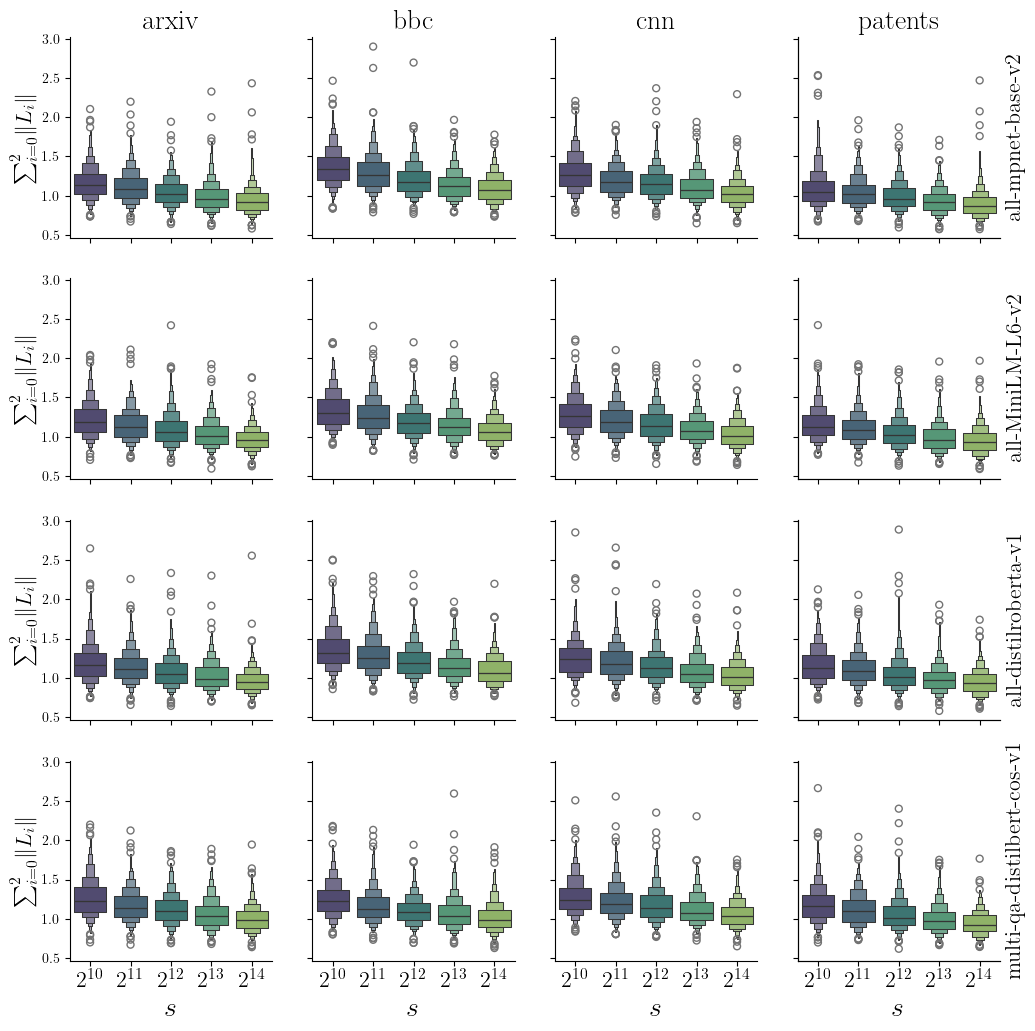

In [176]:
fig, ax = plt.subplots(len(datasets),len(models), figsize=(len(models) * 3, len(datasets) * 3), sharey=True, sharex=True)
for idx, model in enumerate(sorted_models):
    for idx2,dataset in enumerate(sorted_datasets):
        sns.boxenplot(data=all_norms_df.query("model == @model and dataset == @dataset"), x="n_samples", y="score", ax=ax[idx][idx2], palette="viridis",
                      saturation=0.5,
                      legend=False if idx != 3 else True)
        ax[0][idx2].set_title(dataset, fontsize=title_fontsize)
    twinx = ax[idx][-1].twinx()
    twinx.set_yticks([])
    twinx.set_ylabel(model, fontsize=label_fontsize)
for axx in ax.ravel():
    axx.set_ylabel(r"$\sum_{i=0}^2\lVert L_i \rVert$", fontsize=label_fontsize)
    axx.set_xticklabels([r"$2^{"+str(x)+"}$" for x in range(10,15)],fontsize=label_fontsize)
    axx.set_xlabel("$s$", fontsize=title_fontsize)
sns.despine(fig)
plt.savefig(f"{paper_figure_path}/boxen_landscape-norms.pdf", bbox_inches="tight", transparent=True)

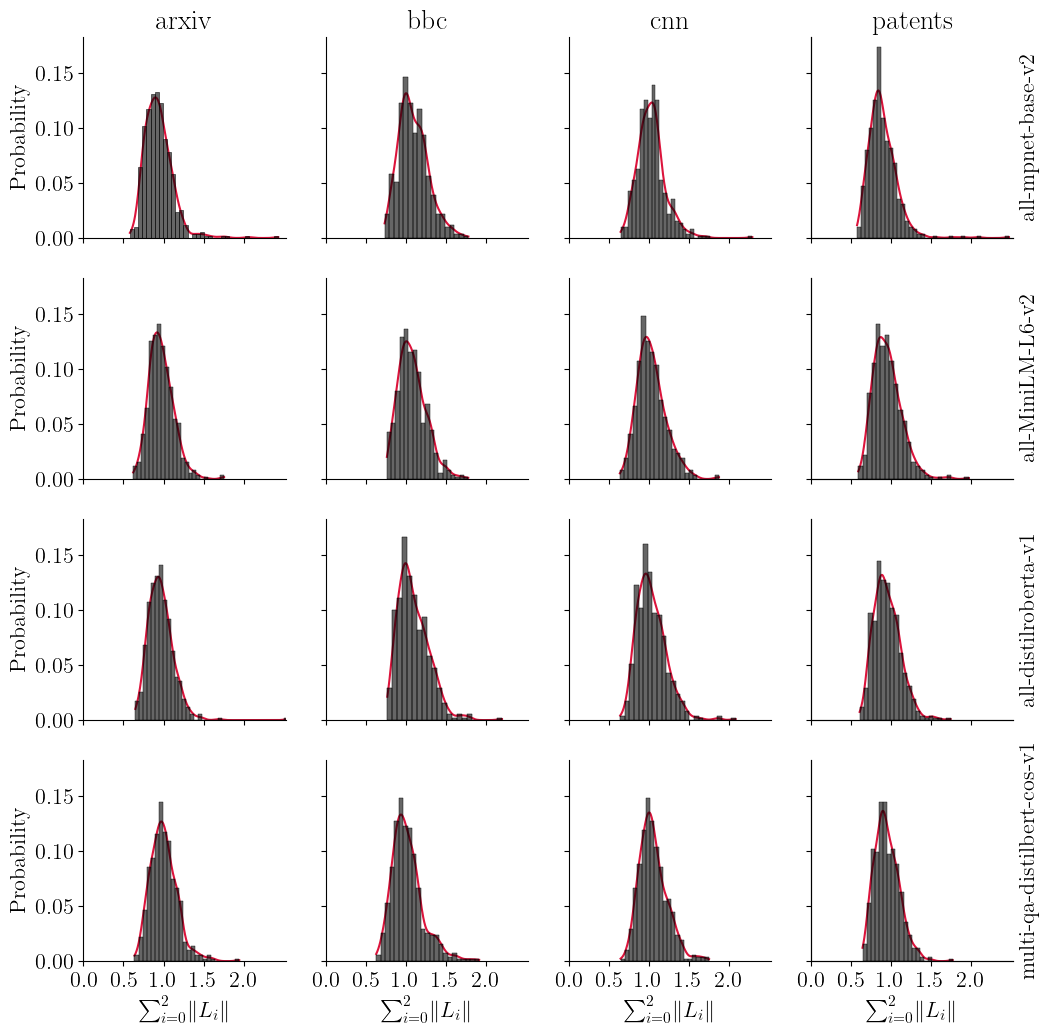

In [192]:
fig, ax = plt.subplots(len(datasets),len(models), figsize=(len(models) * 3, len(datasets) * 3), sharey=True, sharex=True)
for idx, model in enumerate(sorted_models):
    for idx2,dataset in enumerate(sorted_datasets):
        landscapes = results[get_long_name(dataset)][model][16384]["landscapes"]
        landscape_norms_agg = [sum(np.linalg.norm(x) for x in [landscapes[0][idx], landscapes[1][idx], landscapes[2][idx]]) for idx in range(len(landscapes[0]))]
        sns.histplot(landscape_norms_agg, ax=ax[idx][idx2], stat="probability", kde=True, color="k", alpha=0.6)
        ax[idx][idx2].lines[0].set_color('crimson')
        ax[idx][idx2].lines[0].set_zorder(-1)
        ax[idx][idx2].set_xlim(0,ax[idx][idx2].get_xlim()[-1])
        ax[idx][idx2].set_xlabel(r"$\sum_{i=0}^2\lVert L_i \rVert$", fontsize=label_fontsize)
        ax[idx][idx2].set_ylabel("Probability", fontsize=label_fontsize)
        ax[0][idx2].set_title(dataset, fontsize=title_fontsize)
        xticks = [0,0.5,1,1.5,2]
        ax[idx][idx2].set_xticks(xticks)
        ax[idx][idx2].set_xticklabels([f"{x:.1f}" for x in xticks], fontsize=label_fontsize)
        yticks = [0.00, 0.05, 0.10, 0.15]
        ax[idx][idx2].set_yticks(yticks)
        ax[idx][idx2].set_yticklabels([f"{x:.2f}" for x in yticks], fontsize=label_fontsize)
    axx = ax[idx][-1].twinx()
    axx.set_ylabel(model, fontsize=label_fontsize)
    axx.set_yticks([])
sns.despine(fig)
plt.savefig(f"{paper_figure_path}/distributions_landscape-norms.pdf", bbox_inches="tight", transparent=True)

## Below is old

### Exploring Latent Spaces of Sentence Transformers
Thus far, looking at 
- self-similarity of datasets (noise introduced due to projection), 
- impact of dataset on our assessment,
- impact of n_projections choice on our assessment

Not sure what to make of the results tbh

In [10]:


embeddings = dict()
dataset = config.datasets[0]
n_samples = config.n_samples[0]

for model in models:
    with open(f"embeddings_{re.sub(' ', '___', dataset)}_{n_samples}_{model}.pkl", "rb") as f:
        embeddings[model] = pickle.load(f)

embedding_combinations = list(combinations(embeddings, 2)) + [(e,e) for e in embeddings]

### TODO cleanup
Same dataset, different models, different number of projections (should look at comparisons under PCA w/ different initializations, too)

In [12]:
scores = {c:list() for c in embedding_combinations}
presto_objects = {c:list() for c in embedding_combinations}
for n_projections in config.n_projections[2:3]:
    for e1, e2 in embedding_combinations:
        metric = Presto(max_homology_dim=config.max_homology_dim, n_components=config.n_components, normalize=config.normalize)
        score = metric.fit_transform(embeddings[e1], embeddings[e2], N=n_projections, score_type="aggregate")
        presto_objects[e1,e2].append(metric)
        scores[e1,e2].append(score)
        print(e1, e2, n_projections, score)

all-mpnet-base-v2 all-MiniLM-L6-v2 16 0.16975699624406634
all-mpnet-base-v2 all-distilroberta-v1 16 0.19449708943426838
all-mpnet-base-v2 multi-qa-distilbert-cos-v1 16 0.1447599827309606
all-MiniLM-L6-v2 all-distilroberta-v1 16 0.16415739286879097
all-MiniLM-L6-v2 multi-qa-distilbert-cos-v1 16 0.141268234800346
all-distilroberta-v1 multi-qa-distilbert-cos-v1 16 0.21961972672756228
all-mpnet-base-v2 all-mpnet-base-v2 16 0.1570568112690439
all-MiniLM-L6-v2 all-MiniLM-L6-v2 16 0.18392066687148886
all-distilroberta-v1 all-distilroberta-v1 16 0.2422313146255304
multi-qa-distilbert-cos-v1 multi-qa-distilbert-cos-v1 16 0.15541887386767733


In [24]:
with open(f"presto-objects_cnn_{n_samples}_normalized-{config.normalize}.pkl", "wb") as f:
    pickle.dump(presto_objects, f)
with open(f"scores_cnn_{n_samples}_normalized-{config.normalize}.pkl", "wb") as f:
    pickle.dump(scores, f)

In [26]:
df = pd.DataFrame.from_records(scores)
df["n_projections"] = config.n_projections[:6]
df

,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)","(all-MiniLM-L6-v2, all-distilroberta-v1)","(all-MiniLM-L6-v2, multi-qa-distilbert-cos-v1)","(all-distilroberta-v1, all-distilroberta-v1)","(all-distilroberta-v1, multi-qa-distilbert-cos-v1)","(all-mpnet-base-v2, all-MiniLM-L6-v2)","(all-mpnet-base-v2, all-distilroberta-v1)","(all-mpnet-base-v2, all-mpnet-base-v2)","(all-mpnet-base-v2, multi-qa-distilbert-cos-v1)","(multi-qa-distilbert-cos-v1, multi-qa-distilbert-cos-v1)",n_projections
0,0.295682,0.272834,0.242314,0.281481,0.648453,0.225095,0.358418,0.316168,0.416772,0.224383,4
1,0.167994,0.151546,0.349840,0.310389,0.300237,0.174486,0.299249,0.374607,0.231556,0.241933,8
2,0.277847,0.141369,0.120354,0.274087,0.216557,0.279866,0.152738,0.264671,0.168364,0.237447,16
3,0.205368,0.129020,0.151125,0.205366,0.120048,0.152587,0.090784,0.072832,0.162585,0.118735,32
4,0.134400,0.075782,0.098200,0.076133,0.148071,0.047589,0.095023,0.085921,0.137962,0.055034,64
5,0.046003,0.068635,0.094029,0.107640,0.059286,0.094387,0.110778,0.068069,0.079345,0.106406,128


In [27]:
melted_df = df.melt(id_vars=["n_projections"])
melted_df.head()

,n_projections,variable,value
0,4,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.295682
1,8,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.167994
2,16,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.277847
3,32,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.205368
4,64,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.134400


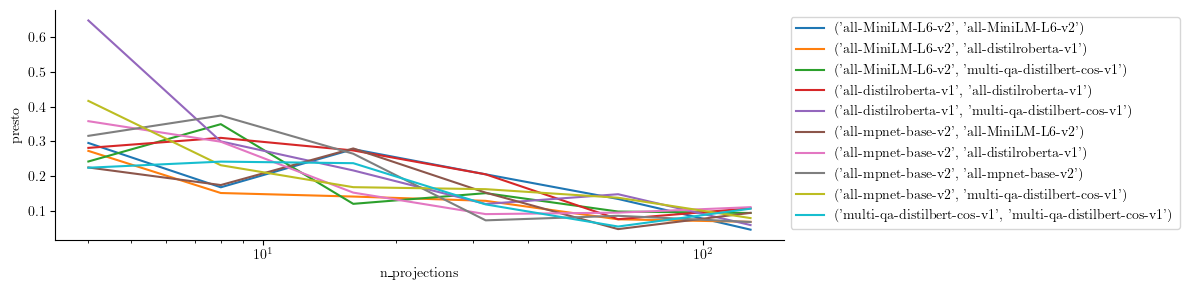

In [29]:
fig, ax = plt.subplots(1,1,figsize=(12,3))
sns.lineplot(melted_df, x="n_projections", y="value", hue="variable")
sns.despine(fig)
ax.set_xscale("log")
ax.set_ylabel("presto")
plt.legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(f"presto_cnn_{n_samples}_scores.pdf", bbox_inches="tight", transparent=True)